In [1]:
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 42

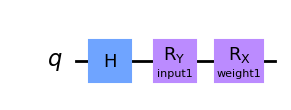

In [2]:
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

params1 = [Parameter("input1"), Parameter("weight1")]
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.ry(params1[0], 0)
qc1.rx(params1[1], 0)
qc1.draw("mpl", style="clifford")

In [3]:
from qiskit.quantum_info import SparsePauliOp

observable1 = SparsePauliOp.from_list([("Y" * qc1.num_qubits, 1)])

In [5]:
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator as Estimator

estimator = Estimator()
estimator_qnn = EstimatorQNN(
    circuit=qc1,
    observables=observable1,
    input_params=[params1[0]],
    weight_params=[params1[1]],
    estimator=estimator,
)
estimator_qnn


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


---

In [8]:
pip install qiskit_algorithms

  Using cached qiskit_algorithms-0.4.0-py3-none-any.whl.metadata (4.7 kB)
Using cached qiskit_algorithms-0.4.0-py3-none-any.whl (327 kB)
Note: you may need to restart the kernel to use updated packages.


In [17]:
import time
from qiskit_aer import AerSimulator
from qiskit.primitives import Sampler
# ... 其他导入保持不变 ...

# --- 优化点 1: 限制样本量 (QML 研发常规操作) ---
# 1400+ 样本对 VQC 太重了，先取 100 个验证模型
subset_size = 100 
train_features_sub = train_features[:subset_size]
train_labels_sub = train_labels[:subset_size]

# --- 优化点 2: 显式配置高性能模拟器 ---
# 使用 statevector 模式，这比默认的采样模式快几个数量级
backend = AerSimulator(method='statevector')
sampler = Sampler(options={"backend_options": {"method": "statevector"}})

# --- 优化点 3: 实例化 VQC 时传入 sampler ---
vqc = VQC(
    sampler=sampler, # 必须显式传入，否则它会用默认低效的参考实现
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=50),
    callback=lambda weights, obj_value: print(f"Objective Value: {obj_value:.4f}")
)

start = time.time()
vqc.fit(train_features_sub, train_labels_sub)
print(f"训练耗时: {time.time() - start:.2f} 秒")

ImportError: cannot import name 'Sampler' from 'qiskit.primitives' (/Users/junchishen/miniconda3/envs/quant_env/lib/python3.11/site-packages/qiskit/primitives/__init__.py)